In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
T = 252
annual_mu = 0.10
annual_vol = 0.05
daily_mu = annual_mu/T
daily_vol = annual_vol/np.sqrt(T)
n_simulations = 10_000

print(daily_mu)
print(daily_vol)


0.0003968253968253968
0.00314970394174356


In [3]:
returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )
# each row is one simulated year path
# each col is one trading day
# size is n_simulations * T

In [4]:
wealth = 100 * (1+returns).cumprod(axis=1)
wealth

array([[ 99.84301303,  99.41523938,  99.4304969 , ..., 115.51201193,
        116.19476725, 115.89436803],
       [100.06912488, 100.09887521, 100.04166189, ..., 110.92629222,
        110.96735866, 110.64414555],
       [ 99.81503688, 100.13489205, 100.36385012, ..., 111.80899236,
        111.96198472, 112.04693113],
       ...,
       [100.25313985, 100.54330113, 100.51337612, ..., 111.6392575 ,
        111.79298027, 112.12064406],
       [100.26432731, 100.35601914, 100.64925803, ..., 101.85397376,
        102.03264895, 101.86414981],
       [100.05410159, 100.53420826, 100.91133907, ..., 107.54932308,
        107.7019584 , 108.00160107]], shape=(10000, 252))

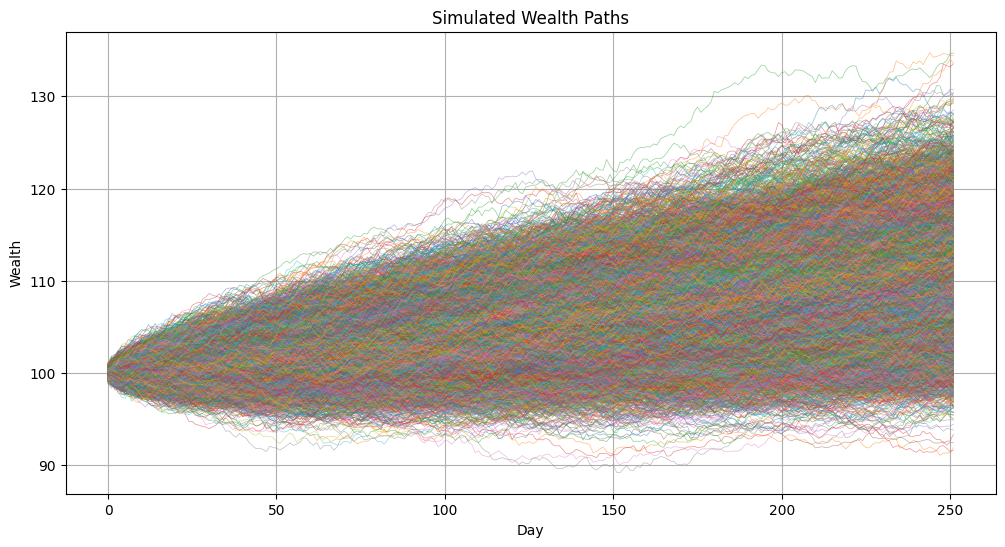

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(wealth.T, alpha=0.5, linewidth=0.5)

plt.xlabel("Day")
plt.ylabel("Wealth")
plt.title("Simulated Wealth Paths")
plt.grid(True)

plt.show()

In [6]:
terminal_wealth = wealth[:, -1]
terminal_wealth

array([115.89436803, 110.64414555, 112.04693113, ..., 112.12064406,
       101.86414981, 108.00160107], shape=(10000,))

In [7]:
percentiles = np.percentile(terminal_wealth, [25, 50, 75])
print(terminal_wealth.mean())
print(percentiles)

110.55202470639239
[106.72435019 110.43128259 114.19345772]


In [8]:
T = 252

annual_mu = 0.10

daily_mu = annual_mu / T

vols = [0.05, 0.10, 0.20, 0.30, 0.50]

n_simulations = 10_000


results = []

for annual_vol in vols:

    daily_vol = annual_vol / np.sqrt(252)

    returns = np.random.normal(
        daily_mu,
        daily_vol,
        size=(n_simulations, T)
    )

    wealth = 100 * np.prod(1 + returns, axis=1)

    terminal_wealth = wealth[:-1]
    percentiles = np.percentile(terminal_wealth,[25,50,75])

    results.append({
        "vol": annual_vol,
        "mean_wealth": wealth.mean(),
        "25th percentile wealth": percentiles[0],
        "50th percentile wealth": percentiles[1],
        "75th percentile wealth": percentiles[2],
        "mean_log_growth": np.mean(
            np.sum(np.log1p(returns), axis=1)
        )
    })

In [9]:
results

[{'vol': 0.05,
  'mean_wealth': np.float64(110.51656768287684),
  '25th percentile wealth': np.float64(106.70830627286178),
  '50th percentile wealth': np.float64(110.35888496580422),
  '75th percentile wealth': np.float64(114.18380233353159),
  'mean_log_growth': np.float64(0.09873268487780901)},
 {'vol': 0.1,
  'mean_wealth': np.float64(110.27024111954677),
  '25th percentile wealth': np.float64(102.50780715118977),
  '50th percentile wealth': np.float64(109.7377355900387),
  '75th percentile wealth': np.float64(117.6071484528452),
  'mean_log_growth': np.float64(0.09268617022324434)},
 {'vol': 0.2,
  'mean_wealth': np.float64(110.6068181031914),
  '25th percentile wealth': np.float64(94.57436151135953),
  '50th percentile wealth': np.float64(108.42215887707304),
  '75th percentile wealth': np.float64(124.23297557801904),
  'mean_log_growth': np.float64(0.08045194051237707)},
 {'vol': 0.3,
  'mean_wealth': np.float64(110.42335710983684),
  '25th percentile wealth': np.float64(86.6428